# LAB-D4-03 Instructor Solution: You Get One Experiment

**Purpose:** Design one falsifiable major change, reproduce it with a fresh harness, and compare quality, latency, and size with a complete serializable record.

**Objectives:** `OBJ-D4-04`, `OBJ-D4-05`, `OBJ-D4-06`  
**Estimated duration:** 50 minutes live; completed CPU path under 8 minutes  
**Prerequisites:** [LESSON-D4-04](../../day-4/student-guide/day-4-student-guide.md#lesson-d4-04---one-experiment-should-teach-one-clear-thing), [LESSON-D4-05](../../day-4/student-guide/day-4-student-guide.md#lesson-d4-05---reproducibility-makes-evidence-shareable), [LESSON-D4-06](../../day-4/student-guide/day-4-student-guide.md#lesson-d4-06---quality-lives-on-a-resource-frontier), [ACT-D4-03](../../day-4/challenges/day-4-challenges.md#act-d4-03---speed-quality-trade-off), and `LAB-D4-02`  
**Environment:** CPU; PyTorch, NumPy, matplotlib, scikit-learn; fixed local digits split; no network

Workflow: **Inspect baseline -> State hypothesis -> Reject confounded draft -> Change one major factor -> Run fresh -> Rerun fresh -> Check tolerance -> Benchmark -> Serialize -> Accept/reject -> Name next experiment without running it**.

In [1]:
import hashlib
import json
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sklearn
import torch
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, f1_score

torch.set_num_threads(1)
started_lab = time.perf_counter()

def find_repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "courseware/shared/data/day-4/manifest.json").exists(): return candidate
    raise FileNotFoundError("Run from the repository checkout with courseware/shared/data/day-4 present.")

ROOT = find_repo_root(); DATA_DIR = ROOT / "courseware/shared/data/day-4"
manifest = json.loads((DATA_DIR / "manifest.json").read_text())
print(f"Python {platform.python_version()} | torch {torch.__version__} | scikit-learn {sklearn.__version__}")
print("Seeds support repeatability on this stack; they do not promise cross-device or cross-release bitwise equality.")

Python 3.11.8 | torch 2.6.0 | scikit-learn 1.9.0
Seeds support repeatability on this stack; they do not promise cross-device or cross-release bitwise equality.


## Fixed Data and Baseline Contract

The fixed stratified split hash owns comparison validity. The packaged baseline supplies curves, validation metrics, parameter bytes, and warmed repeated batch-1 latency. This notebook reloads the digits source and independently trains every participant experiment.

In [2]:
digits = load_digits(); X_all = digits.images.astype(np.float32); y_all = digits.target.astype(np.int64)
splits = np.load(DATA_DIR / manifest["artifacts"]["fixed_splits"]["path"], allow_pickle=False)
train_indices, val_indices, test_indices = splits["train_indices"], splits["val_indices"], splits["test_indices"]
split_hash = str(splits["split_hash"])
assert split_hash == manifest["fixed_split"]["hash"]
X_all_tensor = torch.tensor(X_all / 16.0, dtype=torch.float32)
y_all_tensor = torch.tensor(y_all, dtype=torch.long)
baseline = np.load(DATA_DIR / manifest["artifacts"]["experiment_baseline"]["path"], allow_pickle=False)
baseline_summary = {
    "validation_accuracy": float(baseline["val_accuracy"][-1]),
    "validation_macro_f1": float(f1_score(baseline["val_labels"], baseline["val_predictions"], average="macro", zero_division=0)),
    "parameter_bytes": int(baseline["parameter_bytes"]),
    "latency_ms": float(baseline["latency_ms_median"]),
}
assert 0.88 <= baseline_summary["validation_accuracy"] <= 0.94
print("Split hash:", split_hash); print("Baseline:", baseline_summary)

Split hash: c9a534c56d9b1bb069bc2295d7adf87517e34b69ea9a5b046b79a3b29470b3d9
Baseline: {'validation_accuracy': 0.8969359397888184, 'validation_macro_f1': 0.8940434487656713, 'parameter_bytes': 9640, 'latency_ms': 0.0105}


In [3]:
import random
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cpu")

def set_all_seeds(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

class DigitsMLP(nn.Module):
    def __init__(self, hidden=(32,), dropout=0.0):
        super().__init__(); layers = [nn.Flatten()]; input_dim = 64
        for width in hidden:
            layers.extend([nn.Linear(input_dim, width), nn.ReLU()])
            if dropout > 0: layers.append(nn.Dropout(dropout))
            input_dim = width
        layers.append(nn.Linear(input_dim, 10)); self.network = nn.Sequential(*layers)
    def forward(self, inputs): return self.network(inputs)

def evaluate_model(model, X, y):
    model.eval()
    with torch.inference_mode():
        logits = model(X); probabilities = torch.softmax(logits, dim=1).cpu().numpy()
    predictions = probabilities.argmax(1); targets = y.cpu().numpy()
    return {
        "loss": float(nn.CrossEntropyLoss()(logits, y).item()),
        "accuracy": float(accuracy_score(targets, predictions)),
        "macro_f1": float(f1_score(targets, predictions, average="macro", zero_division=0)),
        "probabilities": probabilities, "predictions": predictions,
    }

def run_experiment(config, train_indices, val_indices):
    set_all_seeds(config["seed"])
    model = DigitsMLP(tuple(config["hidden"]), config["dropout"]).to(DEVICE)
    optimizer_class = {"adam": torch.optim.Adam, "adamw": torch.optim.AdamW, "sgd": torch.optim.SGD}[config["optimizer_name"]]
    extra = {"momentum": 0.9} if config["optimizer_name"] == "sgd" else {}
    optimizer = optimizer_class(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"], **extra)
    selected_labels = y_all[train_indices]
    if config["class_weight"]:
        counts = np.bincount(selected_labels, minlength=10); weights = len(selected_labels) / (10 * np.maximum(counts, 1))
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32))
    else: loss_fn = nn.CrossEntropyLoss()
    generator = torch.Generator().manual_seed(4403 + config["seed"])
    loader = DataLoader(TensorDataset(X_all_tensor[train_indices], y_all_tensor[train_indices]), batch_size=config["batch_size"], shuffle=True, generator=generator, num_workers=0)
    history = {name: [] for name in ["train_loss", "val_loss", "train_accuracy", "val_accuracy"]}; started = time.perf_counter()
    for _ in range(config["epochs"]):
        model.train()
        for X_batch, y_batch in loader:
            optimizer.zero_grad(); loss = loss_fn(model(X_batch), y_batch); loss.backward(); optimizer.step()
        train_metrics = evaluate_model(model, X_all_tensor[train_indices], y_all_tensor[train_indices])
        val_metrics = evaluate_model(model, X_all_tensor[val_indices], y_all_tensor[val_indices])
        for prefix, values in [("train", train_metrics), ("val", val_metrics)]:
            history[f"{prefix}_loss"].append(values["loss"]); history[f"{prefix}_accuracy"].append(values["accuracy"])
    return {"model": model, "config": dict(config), "history": history,
            "train": evaluate_model(model, X_all_tensor[train_indices], y_all_tensor[train_indices]),
            "validation": evaluate_model(model, X_all_tensor[val_indices], y_all_tensor[val_indices]),
            "training_seconds": time.perf_counter() - started,
            "parameter_count": sum(p.numel() for p in model.parameters()),
            "parameter_bytes": sum(p.numel() * p.element_size() for p in model.parameters())}

def benchmark_batch1(model, sample, warmup=20, repeats=100):
    model.eval(); timings = []
    with torch.inference_mode():
        for _ in range(warmup): model(sample)
        for _ in range(repeats):
            started = time.perf_counter(); model(sample); timings.append((time.perf_counter() - started) * 1000)
    return {"median_ms": float(np.median(timings)), "p90_ms": float(np.percentile(timings, 90)), "warmup": warmup, "repeats": repeats}

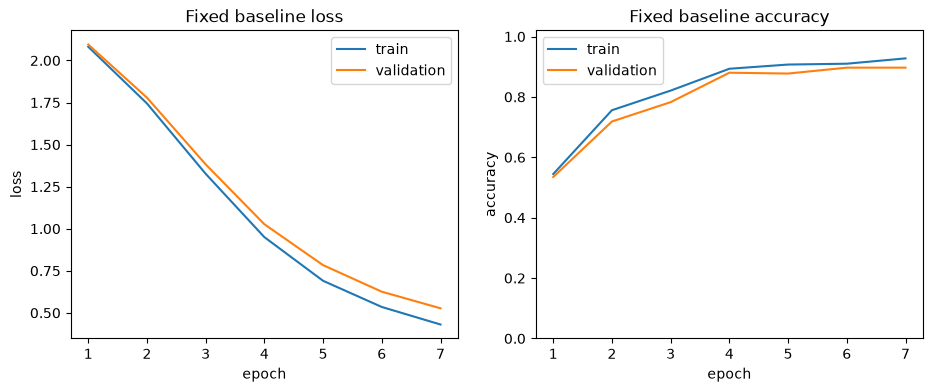

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(baseline["epochs"], baseline["train_loss"], label="train"); axes[0].plot(baseline["epochs"], baseline["val_loss"], label="validation")
axes[0].set(title="Fixed baseline loss", xlabel="epoch", ylabel="loss"); axes[0].legend()
axes[1].plot(baseline["epochs"], baseline["train_accuracy"], label="train"); axes[1].plot(baseline["epochs"], baseline["val_accuracy"], label="validation")
axes[1].set(title="Fixed baseline accuracy", xlabel="epoch", ylabel="accuracy", ylim=(0,1.02)); axes[1].legend(); plt.show()

## Choose One Major Factor

Menu: learning rate, hidden width, weight decay, class weighting, or optimizer. State expected metric, curve, and resource effects plus evidence that rejects the hypothesis.

In [5]:
experiment_hypothesis = {
    "baseline_observation": "The fixed baseline reaches about 0.90 validation accuracy after seven epochs.",
    "mechanism": "A smaller learning rate may learn more smoothly but could be too slow for the fixed epoch budget.",
    "single_factor": "learning_rate only",
    "predicted_metric_effect": "Validation macro-F1 may remain within 0.02 or decline if optimization is too slow.",
    "predicted_curve_effect": "Loss should fall more slowly and smoothly.",
    "predicted_resource_effect": "Parameter bytes stay fixed; training time and latency should be similar.",
    "disconfirming_evidence": "Large instability or a parameter-size change would contradict the mechanism/contract.",
    "stop_rule": "Two fresh seeded runs at seven epochs, then stop regardless of score.",
}
assert all(value.strip() for value in experiment_hypothesis.values())

In [6]:
BASELINE_CONFIG = {
    "hidden": (32,), "dropout": 0.0, "optimizer_name": "adam", "learning_rate": 0.003,
    "weight_decay": 0.0, "class_weight": False, "epochs": 7, "batch_size": 64, "seed": 4402,
}
MAJOR_FIELDS = {"hidden", "optimizer_name", "learning_rate", "weight_decay", "class_weight"}
INTERVENTION_MENU = {
    "hidden": [(16,), (64,)],
    "optimizer_name": ["sgd", "adamw"],
    "learning_rate": [0.001, 0.01],
    "weight_decay": [0.001, 0.01],
    "class_weight": [True],
}

def major_changes(baseline_config, proposed_config):
    return [field for field in MAJOR_FIELDS if proposed_config[field] != baseline_config[field]]

def validate_one_major_change(baseline_config, proposed_config):
    changes = major_changes(baseline_config, proposed_config)
    if len(changes) != 1:
        raise ValueError(f"Exactly one major change required; received {changes}")
    changed_field = changes[0]
    if proposed_config[changed_field] not in INTERVENTION_MENU[changed_field]:
        raise ValueError(f"{changed_field} must use one bounded menu value: {INTERVENTION_MENU[changed_field]}")
    if proposed_config["epochs"] > 20:
        raise ValueError("Epoch budget exceeds the bounded lab contract")
    json.dumps(proposed_config)
    return changed_field

## Deliberate Failure: Three Changes

The draft below changes width, optimizer, and learning rate. It must fail before compute is spent.

In [7]:
confounded_draft = {**BASELINE_CONFIG, "hidden": (128,), "optimizer_name": "sgd", "learning_rate": 0.03}
try:
    validate_one_major_change(BASELINE_CONFIG, confounded_draft)
    raise AssertionError("The confounded draft should not pass")
except ValueError as error:
    print("Expected experiment-design diagnostic:", error)

Expected experiment-design diagnostic: Exactly one major change required; received ['optimizer_name', 'hidden', 'learning_rate']


## Focused TODO: Select the Experiment

Edit exactly one major field. Epochs, split, seed, batch size, measurement method, and device stay fixed for attribution.

In [8]:
PROPOSED_CONFIG = dict(BASELINE_CONFIG)
PROPOSED_CONFIG["learning_rate"] = 0.001
CHANGED_FACTOR = validate_one_major_change(BASELINE_CONFIG, PROPOSED_CONFIG)
print("Authorized factor:", CHANGED_FACTOR)

Authorized factor: learning_rate


## Run Twice From Fresh State

Each call reconstructs model, optimizer, loader, and histories. The same-environment tolerance is absolute difference at most `0.02` for validation accuracy and macro-F1.

In [9]:
first_run = run_experiment(PROPOSED_CONFIG, train_indices, val_indices)
second_run = run_experiment(PROPOSED_CONFIG, train_indices, val_indices)
for metric in ["accuracy", "macro_f1"]:
    difference = abs(first_run["validation"][metric] - second_run["validation"][metric])
    print(metric, "difference", difference)
    assert difference <= 0.02

accuracy difference 0.0
macro_f1 difference 0.0


In [10]:
latency = benchmark_batch1(first_run["model"], X_all_tensor[val_indices[:1]], warmup=20, repeats=100)
print("Intervention validation:", {key: first_run["validation"][key] for key in ["accuracy", "macro_f1"]})
print("Resources:", {"parameter_bytes": first_run["parameter_bytes"], **latency})

Intervention validation: {'accuracy': 0.8495821727019499, 'macro_f1': 0.8444823853608348}
Resources: {'parameter_bytes': 9640, 'median_ms': 0.0100000761449337, 'p90_ms': 0.010666903108358383, 'warmup': 20, 'repeats': 100}


## Focused TODO: Complete the Serializable Record

Record data/split version, seed, full config, device, package versions, metrics, runtime, parameter bytes, timing method, and a checkpoint identity. The checkpoint identity is a record field; the lab does not persist a trained participant model.

In [11]:
experiment_record = {
    "record_schema": 1,
    "run_id": "d4-03-lr-0001-seed-4402",
    "split_hash": split_hash,
    "data_source": "sklearn.datasets.load_digits",
    "seed": PROPOSED_CONFIG["seed"],
    "device": str(DEVICE),
    "versions": {"torch": torch.__version__, "numpy": np.__version__, "sklearn": sklearn.__version__},
    "changed_factor": CHANGED_FACTOR,
    "config": PROPOSED_CONFIG,
    "metrics": {"accuracy": first_run["validation"]["accuracy"], "macro_f1": first_run["validation"]["macro_f1"]},
    "repeat_metrics": {"accuracy": second_run["validation"]["accuracy"], "macro_f1": second_run["validation"]["macro_f1"]},
    "training_seconds": first_run["training_seconds"],
    "parameter_count": first_run["parameter_count"],
    "parameter_bytes": first_run["parameter_bytes"],
    "latency": latency,
    "checkpoint_identity": "digits-mlp-lr0001-s4402-split-c9a534c5",
}
assert experiment_record["run_id"] and experiment_record["checkpoint_identity"]
serialized_record = json.dumps(experiment_record, sort_keys=True, indent=2)
print(serialized_record)

{
  "changed_factor": "learning_rate",
  "checkpoint_identity": "digits-mlp-lr0001-s4402-split-c9a534c5",
  "config": {
    "batch_size": 64,
    "class_weight": false,
    "dropout": 0.0,
    "epochs": 7,
    "hidden": [
      32
    ],
    "learning_rate": 0.001,
    "optimizer_name": "adam",
    "seed": 4402,
    "weight_decay": 0.0
  },
  "data_source": "sklearn.datasets.load_digits",
  "device": "cpu",
  "latency": {
    "median_ms": 0.0100000761449337,
    "p90_ms": 0.010666903108358383,
    "repeats": 100,
    "warmup": 20
  },
  "metrics": {
    "accuracy": 0.8495821727019499,
    "macro_f1": 0.8444823853608348
  },
  "parameter_bytes": 9640,
  "parameter_count": 2410,
  "record_schema": 1,
  "repeat_metrics": {
    "accuracy": 0.8495821727019499,
    "macro_f1": 0.8444823853608348
  },
  "run_id": "d4-03-lr-0001-seed-4402",
  "seed": 4402,
  "split_hash": "c9a534c56d9b1bb069bc2295d7adf87517e34b69ea9a5b046b79a3b29470b3d9",
  "training_seconds": 0.08664054097607732,
  "versions"

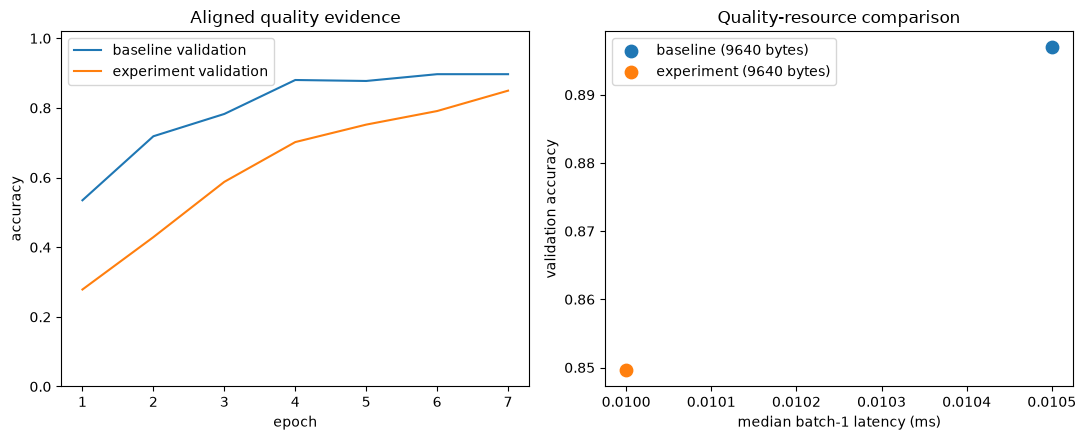

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(baseline["epochs"], baseline["val_accuracy"], label="baseline validation")
axes[0].plot(range(1, len(first_run["history"]["val_accuracy"]) + 1), first_run["history"]["val_accuracy"], label="experiment validation")
axes[0].set(title="Aligned quality evidence", xlabel="epoch", ylabel="accuracy", ylim=(0,1.02)); axes[0].legend()
axes[1].scatter(baseline_summary["latency_ms"], baseline_summary["validation_accuracy"], s=80, label=f"baseline ({baseline_summary['parameter_bytes']} bytes)")
axes[1].scatter(latency["median_ms"], first_run["validation"]["accuracy"], s=80, label=f"experiment ({first_run['parameter_bytes']} bytes)")
axes[1].set(title="Quality-resource comparison", xlabel="median batch-1 latency (ms)", ylabel="validation accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

## Interpret: Information Before Improvement

A clean negative result can resolve a hypothesis. Accept or reject based on predicted mechanism, metric evidence, repeatability, and the stated resource constraint.

In [13]:
accuracy_delta = first_run["validation"]["accuracy"] - baseline_summary["validation_accuracy"]
experiment_decision = {
    "hypothesis_supported": "The slower-learning mechanism is supported if loss descends smoothly but final quality is lower.",
    "metric_delta": f"Validation accuracy delta is {accuracy_delta:+.4f}.",
    "curve_evidence": "Compare the aligned validation curves under the same seven-epoch budget.",
    "repeatability_evidence": "The two fresh seeded runs match within the declared 0.02 tolerance.",
    "resource_tradeoff": "Parameter bytes are unchanged; report warmed batch-1 median and p90 latency.",
    "accept_or_reject": "Reject this intervention if it materially worsens quality under the fixed budget.",
    "next_single_experiment_not_run": "Test one longer-budget condition without changing learning rate.",
    "remaining_uncertainty": "A longer budget may separate slow convergence from a poor asymptotic setting.",
}
assert all(value.strip() for value in experiment_decision.values())

## Optional Bounded Rerun: Seed Variation

Only after the core record is complete, change the seed alone for a sensitivity check. This is not a second intervention and must be labeled separately from same-seed reproduction.

In [14]:
RUN_OPTIONAL_SEED_VARIATION = True
optional_seed_interpretation = {
    "difference": "Record the alternate-seed validation accuracy beside the primary run.",
    "what_it_does_not_prove": "One extra seed does not establish distributional robustness or cross-platform identity.",
}
if RUN_OPTIONAL_SEED_VARIATION:
    optional_config = {**PROPOSED_CONFIG, "seed": PROPOSED_CONFIG["seed"] + 1}
    optional_run = run_experiment(optional_config, train_indices, val_indices)
    print("Optional seed validation accuracy:", optional_run["validation"]["accuracy"])
    assert all(value.strip() for value in optional_seed_interpretation.values())

Optional seed validation accuracy: 0.7910863509749304


## Challenge: Deployment Constraint Changes

Re-evaluate the same two measured points under one constraint: maximum model bytes, maximum median latency, or minimum macro-F1. Do not run another model. State whether either point is dominated and which production facts this classroom benchmark omits.

In [15]:
deployment_decision = {
    "constraint": "Prefer the higher validation accuracy when size and measured latency are effectively tied.",
    "chosen_point": "Retain the baseline if the slower-learning run loses quality.",
    "dominated_or_not": "The intervention is dominated if it is no smaller/faster and less accurate.",
    "missing_production_measurements": "Tail latency, throughput, peak memory, energy, and service integration cost.",
}
assert all(value.strip() for value in deployment_decision.values())

## Reflection, Takeaways, and Troubleshooting

- Change one major factor when attribution is the learning goal.
- Reset model, optimizer, loader, and seeds for every run.
- A record needs split identity, complete config, environment, metrics, resources, and checkpoint identity.
- Warm up and repeat latency; batch-1 latency is not throughput or production tail latency.

| Symptom | Likely cause | Recovery |
|---|---|---|
| Gate lists several fields | Confounded draft | Reset from `BASELINE_CONFIG` and edit one major field |
| Reruns differ by over `0.02` | State or split was reused/changed | Recreate all state and restore the fixed split |
| Record will not serialize | Tuple/object or missing field | Use JSON-compatible values and complete every identity field |
| Runtime approaches 8 minutes | Epoch/model budget expanded | Restore the bounded menu and CPU thread setting |

In [16]:
assert len(major_changes(BASELINE_CONFIG, PROPOSED_CONFIG)) == 1
assert abs(first_run["validation"]["accuracy"] - second_run["validation"]["accuracy"]) <= 0.02
assert abs(first_run["validation"]["macro_f1"] - second_run["validation"]["macro_f1"]) <= 0.02
json.loads(serialized_record)
assert all(value.strip() for value in experiment_decision.values())
assert all(value.strip() for value in deployment_decision.values())
print(f"LAB-D4-03 checkpoint passed in {time.perf_counter() - started_lab:.2f}s: one factor, two fresh runs, complete record, and quality-resource defense.")

LAB-D4-03 checkpoint passed in 1.08s: one factor, two fresh runs, complete record, and quality-resource defense.


## Continue

Use the Day 4 guide debrief: [LAB-D4-03 Debrief - What Did the Run Buy?](../../day-4/student-guide/day-4-student-guide.md#lab-d4-03-debrief---what-did-the-run-buy).

---

## Instructor Debrief: The Controlled Negative Result

The canonical solution changes only learning rate, `0.003 -> 0.001`, under the fixed seven-epoch budget. It reaches about **0.8496 validation accuracy** and **0.8445 macro-F1**, below the packaged baseline accuracy **0.8969** and macro-F1 **0.8940**. Two freshly constructed same-seed runs match within the declared `0.02` tolerance (exactly on the recorded stack). This is a successful experiment and a rejected intervention: the result separates slow convergence under the fixed budget from an assumption that a smaller learning rate must improve generalization.

The confounded draft changes width, optimizer, and learning rate and must fail before training. The epoch gate also rejects any proposal above 20 epochs. A budget violation is an experiment-design failure, not a reason to silently extend the run.


## Intervention Menu Solution Notes

Every bounded menu option is executable and was exercised during solution validation. Interpret each as one experiment, not as a tuning sweep available to participants.

| Changed factor | Values | Mechanism tested | Resource expectation | Valid rejection evidence |
|---|---|---|---|---|
| hidden width | `(16,)`, `(64,)` | capacity limitation | parameter bytes and often latency change | quality does not move as predicted or trade-off is dominated |
| optimizer | `sgd`, `adamw` | update dynamics/regularization | bytes fixed; training path and timing may change | curves/quality do not improve under fixed budget |
| learning rate | `0.001`, `0.01` | step size too small/large | bytes fixed; latency broadly comparable | instability, slow convergence, or validation regression |
| weight decay | `0.001`, `0.01` | regularization improves held-out behavior | bytes fixed | no gap/validation benefit or underfit regression |
| class weight | `True` | class-frequency-sensitive loss | bytes fixed | class-aware evidence does not improve or aggregate regression exceeds tolerance |

A participant should choose one branch from prior evidence. The instructor validation sweep exists to prove menu executability, not to license post-hoc best-score selection.


## Record, Reproduction, and Resource Method

The JSON-serializable record includes source/split hash, seed, CPU device, package versions, full configuration, changed factor, primary and repeat metrics, training seconds, parameter count/bytes, timing method, and checkpoint identity. Tuples serialize as JSON arrays; a persisted checkpoint identity should additionally bind model state and preprocessing in a real system.

Fresh reproduction means recreating model, optimizer, seeded loader generator, and training state. Reusing a trained model is not a rerun. The optional alternate seed is sensitivity evidence, not same-seed reproduction and not proof of distributional robustness.

Parameter bytes are computed from tensor element counts and element sizes. Batch-1 latency uses evaluation mode, inference mode, 20 warmups, and 100 repeated measurements, reporting median and p90. On accelerators, synchronization is required around timed work; end-to-end service claims also require data transfer, preprocessing, batching, throughput, memory, tail latency, and deployment environment. Host-specific timing differences do not invalidate the method.


## Hint Ladder, Alternatives, and Recovery

1. Ask which baseline observation motivates the proposed factor.
2. Circle every field that differs from baseline.
3. Require predicted metric, curve, and resource directions.
4. Require an observation that would reject the idea.
5. Authorize compute only after the serialized contract can be explained.

Common wrong answers include calling a negative score a failed lab, treating one alternate seed as reproducibility proof, comparing latency without warmup/repeats/environment, or changing epochs alongside the intervention. Acceptable alternatives include confidence intervals over several predeclared seeds, operation counts, peak memory, throughput, or model-file bytes, provided the comparison contract and limitations are explicit.

Run on one CPU thread from the repository root; no network is used. If training fails, preserve the hypothesis and exact configuration, identify the first failed invariant, attempt one bounded repair, and use the matching packaged baseline only for continued reasoning. Do not relabel cached evidence as a live intervention result.
